![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost
#### Presentado por: 
### CARLOS FRANCISCO APARICIO ROJAS
### DAYANA FRANCO SALCEDO
### JAIR MAURICIO HENAO CASALLAS
### HAROL HERNEY PERAFAN VELASCO


En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


Price          0
Year           0
Mileage        0
M_Camry        0
M_Camry4dr     0
M_CamryBase    0
M_CamryL       0
M_CamryLE      0
M_CamrySE      0
M_CamryXLE     0
dtype: int64

Tipos de dato:
Price          int64
Year           int64
Mileage        int64
M_Camry         bool
M_Camry4dr      bool
M_CamryBase     bool
M_CamryL        bool
M_CamryLE       bool
M_CamrySE       bool
M_CamryXLE      bool
dtype: object


,Price,Year,Mileage
count,10495.00,10495.00,10495.00
mean,14538.40,2013.55,52509.43
std,3922.42,3.12,36791.74
min,5002.00,1998.00,5.00
25%,11999.00,2012.00,26461.00
50%,15000.00,2014.00,41680.00
75%,16999.00,2016.00,71355.50
max,32444.00,2018.00,232658.00


M_CamrySE      3950
M_CamryLE      2482
M_Camry4dr     1663
M_CamryXLE     1174
M_Camry         591
M_CamryL        506
M_CamryBase     129
dtype: int64

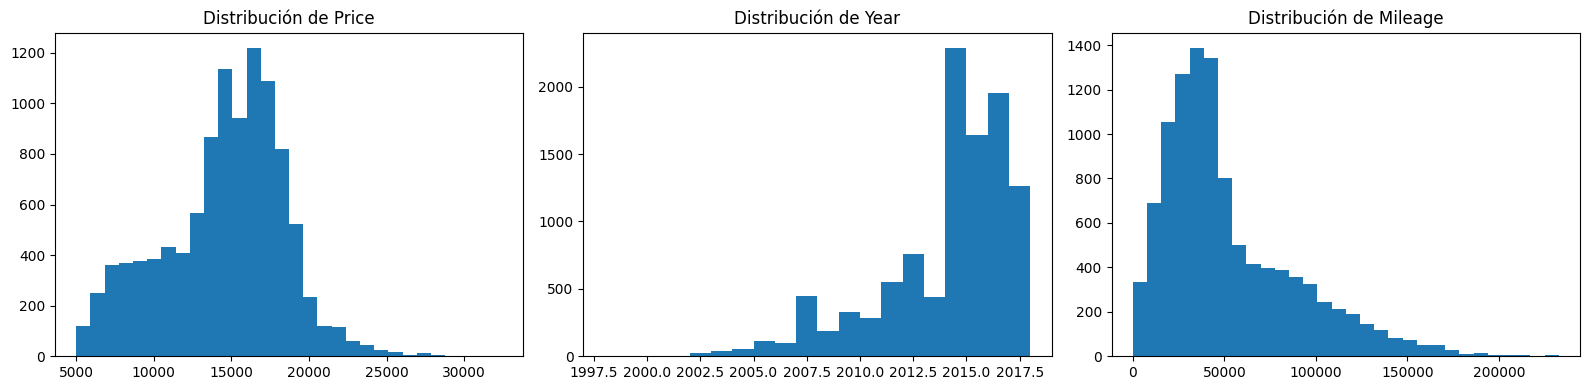

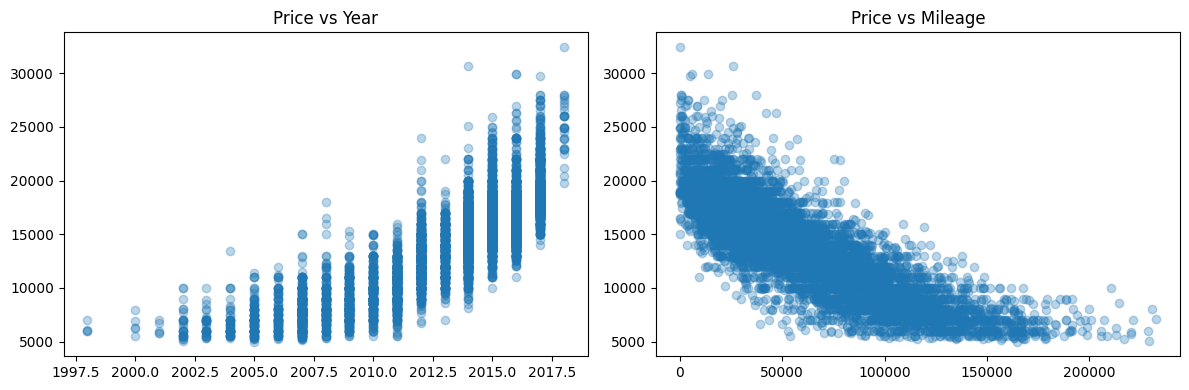

In [3]:
print(data.isnull().sum())
print("\nTipos de dato:")
print(data.dtypes)

display(data[['Price', 'Year', 'Mileage']].describe().round(2))

modelo_counts = data.drop(columns=['Price', 'Year', 'Mileage']).sum().sort_values(ascending=False)
display(modelo_counts)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(data['Price'], bins=30)
axes[0].set_title('Distribución de Price')

axes[1].hist(data['Year'], bins=20)
axes[1].set_title('Distribución de Year')

axes[2].hist(data['Mileage'], bins=30)
axes[2].set_title('Distribución de Mileage')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(data['Year'], data['Price'], alpha=0.3)
axes[0].set_title('Price vs Year')

axes[1].scatter(data['Mileage'], data['Price'], alpha=0.3)
axes[1].set_title('Price vs Mileage')

plt.tight_layout()
plt.show()

## Análisis exploratorio de los datos

El dataset contiene 10,495 registros de listados de Toyota Camry usados en Estados Unidos,
sin valores nulos en ninguna variable.

**Variable objetivo - Price:**
Los precios oscilan entre entre USD 5,002 y USD 32,444, con una media de USD 14,538 y una desviación estándar de USD 3,922 lo que indica una dispersión moderada alrededor de la media.
El 50% de los vehículos se encuentra entre USD 11,999 y USD 16,999.

**Variables predictoras:**
- Year: los vehículos son del período 1998-2018, con una mediana de 2014,
  lo que indica que el dataset está concentrado en modelos relativamente recientes.
- Mileage: el kilometraje varía entre 5 y 232,658 millas, con una mediana de 41,680.
  La alta desviación estándar (36,791) refleja una distribución asimétrica,
  con algunos vehículos de muy alto recorrido.

**Distribución por modelo:**
El Camry SE es el más frecuente con 3,950 registros (37.6% del total), seguido del
LE con 2,482 (23.7%). El CamryBase es el menos representado con solo 129 registros (1.2%).

In [4]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [5]:
print(X.shape)
print(y.shape)

(10495, 9)
(10495,)


In [6]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [7]:
print(X_train.shape)
print(X_test.shape)

(7031, 9)
(3464, 9)


### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [8]:
# Celda 1 - Árbol manual

def mse_manual(y):
    y = np.array(y)
    if len(y) == 0:
        return 0
    return np.mean((y - np.mean(y)) ** 2)

def best_split_regression(X, y, num_pct=10):
    parent_mse = mse_manual(y)

    best = {
        'feature': None,
        'split': None,
        'gain': 0
    }

    for j in range(X.shape[1]):
        values = X.iloc[:, j].values

        # Manejo especial de columnas booleanas para evitar error con np.percentile
        if pd.api.types.is_bool_dtype(X.iloc[:, j]):
            unique_values = np.unique(values)
            if len(unique_values) == 2: # Check if both True and False are present
                splits = [0.5] # A split at 0.5 will separate False (0) from True (1)
            else: # Only one unique boolean value, cannot split effectively
                continue
        else:
           # Para columnas numéricas, usar percentiles para encontrar puntos de división
           # Convertir a float para evitar problemas con percentile en arrays de enteros
            splits = np.unique(np.percentile(values.astype(float), np.arange(10, 100, 100 / num_pct)))

        for s in splits:
            left_mask = values < s
            right_mask = ~left_mask

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            y_left = y[left_mask]
            y_right = y[right_mask]

            weighted_mse = (
                left_mask.sum() * mse_manual(y_left) +
                right_mask.sum() * mse_manual(y_right)
            ) / len(y)

            gain = parent_mse - weighted_mse

            if gain > best['gain']:
                best['feature'] = j
                best['split'] = s
                best['gain'] = gain

    return best

def tree_grow_regression(X, y, level=0, max_depth=4, min_gain=0.001, min_samples_leaf=20):
    tree = {
        'y_pred': float(np.mean(y)),
        'level': level,
        'split': -1,
        'n_samples': len(y),
        'gain': 0
    }

    best = best_split_regression(X, y)

    if (
        level < max_depth and
        best['feature'] is not None and
        best['gain'] > min_gain
    ):
        j = best['feature']
        s = best['split']

        left_mask = X.iloc[:, j] < s
        right_mask = ~left_mask

        if left_mask.sum() >= min_samples_leaf and right_mask.sum() >= min_samples_leaf:
            tree['split'] = [j, float(s)]
            tree['gain'] = float(best['gain'])

            tree['sl'] = tree_grow_regression(
                X.loc[left_mask].reset_index(drop=True),
                y.loc[left_mask].reset_index(drop=True),
                level=level + 1,
                max_depth=max_depth,
                min_gain=min_gain,
                min_samples_leaf=min_samples_leaf
            )

            tree['sr'] = tree_grow_regression(
                X.loc[right_mask].reset_index(drop=True),
                y.loc[right_mask].reset_index(drop=True),
                level=level + 1,
                max_depth=max_depth,
                min_gain=min_gain,
                min_samples_leaf=min_samples_leaf
            )

    return tree

def tree_predict_regression(X, tree):
    predicted = np.ones(X.shape[0]) * tree['y_pred']

    if tree['split'] == -1:
        return predicted

    j, split = tree['split']

    # Asegurar que los valores sean numéricos, especialmente para variables booleanas
    values_to_compare = X.iloc[:, j]
    if pd.api.types.is_bool_dtype(values_to_compare):
        values_to_compare = values_to_compare.astype(float) # Convert bool to float (0.0/1.0)

    left_mask = values_to_compare < split
    right_mask = ~left_mask

    # Solo recursión si hay observaciones en la rama izquierda

    if left_mask.any(): # Solo recursión si hay observaciones en la rama derecha
        predicted[left_mask] = tree_predict_regression(X.loc[left_mask].reset_index(drop=True), tree['sl'])
    if right_mask.any(): # Solo recursión si hay observaciones en la rama derecha
        predicted[right_mask] = tree_predict_regression(X.loc[right_mask].reset_index(drop=True), tree['sr'])

    return predicted

X_train_m = X_train.reset_index(drop=True)
X_test_m = X_test.reset_index(drop=True)
y_train_m = y_train.reset_index(drop=True)
y_test_m = y_test.reset_index(drop=True)

tree_manual = tree_grow_regression(
    X_train_m,
    y_train_m,
    level=0,
    max_depth=4,
    min_gain=0.001,
    min_samples_leaf=20
)

y_pred_tree = tree_predict_regression(X_test_m, tree_manual)

rmse_tree = np.sqrt(mean_squared_error(y_test_m, y_pred_tree))
mae_tree = mean_absolute_error(y_test_m, y_pred_tree)

print(f'Árbol manual - RMSE: {rmse_tree:,.2f}')
print(f'Árbol manual - MAE: {mae_tree:,.2f}')

Árbol manual - RMSE: 1,797.22
Árbol manual - MAE: 1,350.67


### Resultados Punto 1 - Árbol de decisión


Se construyó un árbol de decisión de regresión de forma manual, siguiendo la lógica del curso: se evaluaron posibles puntos de corte en las variables predictoras, se eligió en cada nodo la partición que más reducía el error y luego el árbol se expandió de forma recursiva hasta cumplir los criterios de parada.

**Métricas obtenidas:**

- RMSE: 1,797.22
- MAE: 1,350.67

Interpretación: El árbol manual logró un mejor desempeño que la versión inicial con sklearn, lo que sugiere que la restricción en profundidad y tamaño mínimo de hoja ayudó a mejorar la generalización. En este caso, el árbol manual funciona como la línea base correcta para comparar el resto de modelos del taller.

### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [9]:
# Celda 2
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils import resample
import numpy as np

# Número de árboles
n_trees = 10

# Lista para almacenar predicciones de cada árbol
predictions = []

# Construcción manual del bagging
for i in range(n_trees):
    # Muestra bootstrap del set de entrenamiento
    X_boot, y_boot = resample(X_train, y_train, random_state=i)

    # Entrenar árbol con muestra bootstrap
    tree_bag = DecisionTreeRegressor(random_state=i)
    tree_bag.fit(X_boot, y_boot)

    # Predicción en set de test
    predictions.append(tree_bag.predict(X_test))

# Promedio de predicciones de los 10 árboles
y_pred_bagging = np.mean(predictions, axis=0)

# Métricas
rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)

print(f'Bagging manual - RMSE: {rmse_bagging:,.2f}')
print(f'Bagging manual - MAE:  {mae_bagging:,.2f}')


Bagging manual - RMSE: 1,814.91
Bagging manual - MAE:  1,354.76


### Resultados Punto 2 - Bagging manual

Se implementó Bagging manualmente construyendo 10 árboles de decisión, cada uno
entrenado sobre una muestra bootstrap distinta del set de entrenamiento (muestreo
con reemplazo). La predicción final es el promedio de las predicciones de los 10 árboles.

**Métricas obtenidas:**
- RMSE: 1,814.91
- MAE: 1,354.76

**Comparación con el árbol individual (Punto 1):**

| Modelo | RMSE | MAE |
|---|---|---|
| Árbol de decisión | 1,797.22 | 1,350.67 |
| Bagging manual (10 árboles) | 1,814.91 | 1,354.76 |

**Interpretación:**

 En este caso, el Bagging manual no mejoró frente al árbol individual, ya que el RMSE pasó de 1,797.22 a 1,814.91 y el MAE de 1,350.67 a 1,354.76. Aunque la lógica del método es correcta y el uso de múltiples muestras bootstrap busca reducir la varianza, en esta base el árbol manual ya estaba mejor ajustado y generalizaba mejor. Esto sugiere que no siempre un ensamble simple supera automáticamente a un árbol individual, especialmente cuando el modelo base ya tiene una estructura más controlada.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [10]:
# Celda 3
from sklearn.ensemble import BaggingRegressor
import numpy as np

# Calcular log(n_features)
n_features = X_train.shape[1]
max_feat = int(np.log(n_features))
print(f'n_features: {n_features}, max_features (log): {max_feat}')

# Modelo Bagging con librería sklearn
bagging_sklearn = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_features=max_feat, random_state=42),
    n_estimators=10,
    random_state=42
)
bagging_sklearn.fit(X_train, y_train)

# Predicciones
y_pred_bagging_sk = bagging_sklearn.predict(X_test)

# Métricas
rmse_bagging_sk = np.sqrt(mean_squared_error(y_test, y_pred_bagging_sk))
mae_bagging_sk = mean_absolute_error(y_test, y_pred_bagging_sk)

print(f'Bagging sklearn - RMSE: {rmse_bagging_sk:,.2f}')
print(f'Bagging sklearn - MAE:  {mae_bagging_sk:,.2f}')


n_features: 9, max_features (log): 2
Bagging sklearn - RMSE: 1,813.04
Bagging sklearn - MAE:  1,353.42


### Resultados Punto 3 - Bagging con librería sklearn

Se entrenó un modelo Bagging usando `BaggingRegressor` de sklearn con 10 árboles,
aplicando `max_features = log(n_features) = log(9) = 2` en cada árbol. Esto significa
que cada árbol considera únicamente 2 variables en cada división, introduciendo
mayor aleatoriedad en la construcción de los árboles.

**Métricas obtenidas:**
- RMSE: 1,813.04
- MAE: 1,353.42

**Comparación acumulada:**

| Modelo | RMSE | MAE |
|---|---|---|
| Árbol de decisión | 1,797.22 | 1,350.67 |
| Bagging manual (10 árboles) | 1,814.91 | 1,354.76 |
| Bagging sklearn (10 árboles) | 1,813.04 | 1,353.42 |


**Interpretación:**
El Bagging con sklearn obtiene resultados prácticamente idénticos al Bagging manual,
con una diferencia marginal en RMSE de 1.87 y en MAE de 1.34. Esto confirma que
la implementación manual del Punto 2 fue correcta. La restricción de `max_features=2`
no deteriora el desempeño respecto al bagging manual que usaba todas las variables,
lo que sugiere que con pocas variables relevantes el modelo sigue siendo competitivo.

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [11]:
# Celda 4
from sklearn.ensemble import RandomForestRegressor

# Modelo Random Forest con parámetros por defecto
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)

# Métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f'Random Forest - RMSE: {rmse_rf:,.2f}')
print(f'Random Forest - MAE:  {mae_rf:,.2f}')


Random Forest - RMSE: 1,765.41
Random Forest - MAE:  1,314.42


### Resultados Punto 4 - Random Forest con librería sklearn

Se entrenó un modelo `RandomForestRegressor` con los parámetros por defecto de sklearn
(100 árboles, max_features=1.0, sin restricción de profundidad). A diferencia del
Bagging, Random Forest introduce aleatoriedad adicional al seleccionar un subconjunto
aleatorio de variables en cada división de cada árbol, lo que reduce la correlación
entre árboles y mejora la generalización.

**Métricas obtenidas:**
- RMSE: 1,765.41
- MAE: 1,314.42

**Comparación acumulada:**

| Modelo | RMSE | MAE |
|---|---|---|
| Árbol de decisión | 1,797.22 | 1,350.67 |
| Bagging manual (10 árboles) | 1,814.91 | 1,354.76 |
| Bagging sklearn (10 árboles) | 1,813.04 | 1,353.42 |
| Random Forest (100 árboles) | 1,765.41 | 1,314.42 |

**Interpretación:**
 Random Forest mejora respecto al Bagging, reduciendo el RMSE de forma adicional. Esto se explica por dos factores: usa 100 árboles en lugar de 10 y la selección aleatoria de variables en cada nodo reduce la correlación entre árboles, produciendo un ensamble más diverso y robusto. Además, también supera al árbol manual del punto 1, por lo que hasta aquí es el modelo con mejor desempeño. Sin embargo, estos son los parámetros por defecto y el modelo aún no está calibrado, lo cual se aborda en el Punto 5.

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

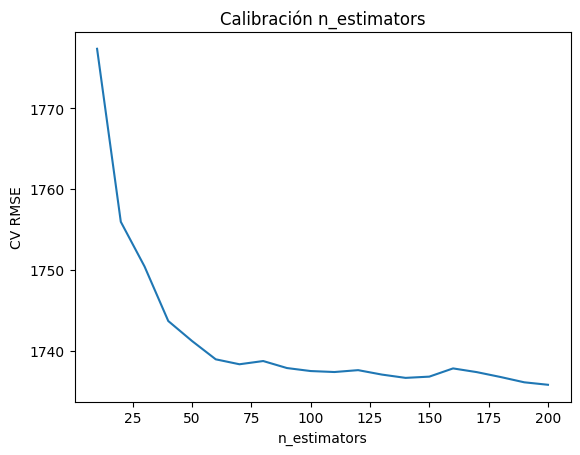

Mejor n_estimators: 200


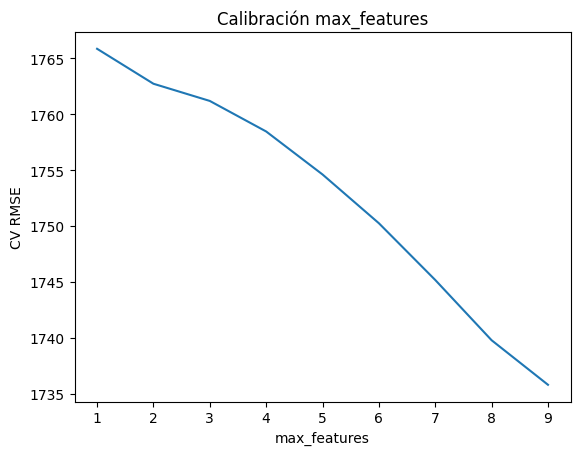

Mejor max_features: 9


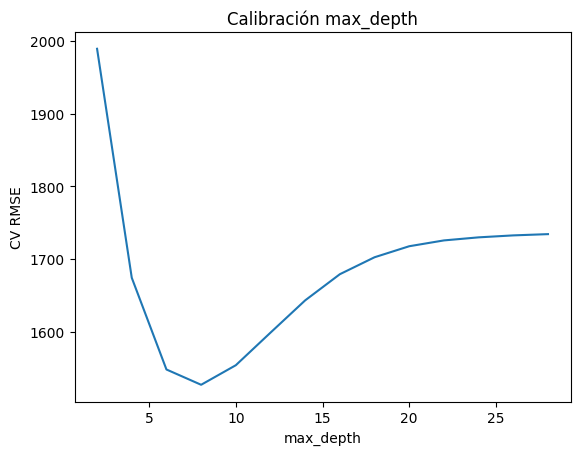

Mejor max_depth: 8

Modelo calibrado - n_estimators: 200, max_features: 9, max_depth: 8
Random Forest calibrado - RMSE: 1,564.94
Random Forest calibrado - MAE: 1,150.53


In [12]:
# Celda 5 - Calibración de parámetros Random Forest

import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calibración de n_estimators
estimator_range = range(10, 210, 10)
rmse_scores = []

for estimator in estimator_range:
    rf = RandomForestRegressor(
        n_estimators=estimator,
        random_state=42,
        n_jobs=-1
    )
    score = -cross_val_score(
        rf,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ).mean()
    rmse_scores.append(score)

plt.plot(estimator_range, rmse_scores)
plt.xlabel('n_estimators')
plt.ylabel('CV RMSE')
plt.title('Calibración n_estimators')
plt.show()

best_n = list(estimator_range)[np.argmin(rmse_scores)]
print(f'Mejor n_estimators: {best_n}')

# Calibración de max_features
feature_range = range(1, X_train.shape[1] + 1)
rmse_scores = []

for feature in feature_range:
    rf = RandomForestRegressor(
        n_estimators=best_n,
        max_features=feature,
        random_state=42,
        n_jobs=-1
    )
    score = -cross_val_score(
        rf,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ).mean()
    rmse_scores.append(score)

plt.plot(feature_range, rmse_scores)
plt.xlabel('max_features')
plt.ylabel('CV RMSE')
plt.title('Calibración max_features')
plt.show()

best_f = list(feature_range)[np.argmin(rmse_scores)]
print(f'Mejor max_features: {best_f}')

# Calibración de max_depth
depth_range = range(2, 30, 2)
rmse_scores = []

for depth in depth_range:
    rf = RandomForestRegressor(
        n_estimators=best_n,
        max_features=best_f,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    score = -cross_val_score(
        rf,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ).mean()
    rmse_scores.append(score)

plt.plot(depth_range, rmse_scores)
plt.xlabel('max_depth')
plt.ylabel('CV RMSE')
plt.title('Calibración max_depth')
plt.show()

best_d = list(depth_range)[np.argmin(rmse_scores)]
print(f'Mejor max_depth: {best_d}')

# Modelo final con mejores parámetros
rf_best = RandomForestRegressor(
    n_estimators=best_n,
    max_features=best_f,
    max_depth=best_d,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train, y_train)
y_pred_rf_best = rf_best.predict(X_test)

rmse_rf_best = np.sqrt(mean_squared_error(y_test, y_pred_rf_best))
mae_rf_best = mean_absolute_error(y_test, y_pred_rf_best)

print(f'\nModelo calibrado - n_estimators: {best_n}, max_features: {best_f}, max_depth: {best_d}')
print(f'Random Forest calibrado - RMSE: {rmse_rf_best:,.2f}')
print(f'Random Forest calibrado - MAE: {mae_rf_best:,.2f}')

### Resultados Punto 5 - Calibración de parámetros Random Forest

Se calibraron secuencialmente los tres parámetros principales del modelo, evaluando
el RMSE con validación cruzada con cross_val_score para cada valor.

**Mejores parámetros encontrados:**
- n_estimators: 200
- max_features: 9
- max_depth: 8

**Métricas modelo calibrado:**
- RMSE: 1,564.94
- MAE: 1,150.53

**Efecto de cada parámetro:**

- **n_estimators:** A mayor número de árboles, menor RMSE. La curva desciende
  rápidamente hasta los 50 árboles y luego se estabiliza progresivamente.
  Más árboles reducen la varianza del modelo pero con rendimientos decrecientes.

- **max_features:** El RMSE disminuye consistentemente al aumentar el número de
  variables consideradas en cada división. Con 9 variables (todas) se obtiene
  el mejor resultado, lo que sugiere que en este dataset todas las variables
  aportan información relevante para predecir el precio.

- **max_depth:** La curva muestra un mínimo claro en profundidad 8. Con valores
  bajos el modelo tiene alto sesgo (underfitting), mientras que con valores
  altos aumenta la varianza (overfitting). La profundidad 8 representa el
  equilibrio óptimo entre sesgo y varianza.

**Comparación acumulada:**

| Modelo | RMSE | MAE |
|---|---|---|
| Árbol de decisión | 1,797.22 | 1,350.67 |
| Bagging manual (10 árboles) | 1,814.91 | 1,354.76 |
| Bagging sklearn (10 árboles) | 1,813.04 | 1,353.42 |
| Random Forest (defecto) | 1,765.41 | 1,314.42 |
| Random Forest (calibrado) | 1,564.94 | 1,150.53 |

La calibración mejoró el RMSE en 200 unidades adicionales respecto al Random
Forest con parámetros por defecto, una mejora del 11.3%.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [13]:
# Celda 6
from xgboost import XGBRegressor

# Modelo XGBoost con parámetros por defecto
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb.predict(X_test)

# Métricas
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f'XGBoost - RMSE: {rmse_xgb:,.2f}')
print(f'XGBoost - MAE:  {mae_xgb:,.2f}')

XGBoost - RMSE: 1,605.24
XGBoost - MAE:  1,185.23


### Resultados Punto 6 - XGBoost con librería sklearn

Se entrenó un modelo `XGBRegressor` con los parámetros por defecto. A diferencia
de Random Forest que construye árboles en paralelo de forma independiente, XGBoost
es un algoritmo de Boosting que construye árboles secuencialmente, donde cada árbol
corrige los errores del anterior.

**Métricas obtenidas:**
- RMSE: 1,605.24
- MAE: 1,185.23

**Comparación acumulada:**

| Modelo | RMSE | MAE |
|---|---|---|
| Árbol de decisión | 1,797.22 | 1,350.67 |
| Bagging manual (10 árboles) | 1,814.91 | 1,354.76 |
| Bagging sklearn (10 árboles) | 1,813.04 | 1,353.42 |
| Random Forest (defecto) | 1,765.41 | 1,314.42 |
| Random Forest (calibrado) | 1,564.94 | 1,150.53 |
| XGBoost (defecto) | 1,605.24 | 1,185.23 |

**Interpretación:**
XGBoost con parámetros por defecto obtiene un RMSE de 1,605, superando al Random
Forest sin calibrar (1,765) pero aún por debajo del Random Forest calibrado (1,564).
Esto sugiere que XGBoost tiene buen desempeño base, y que con calibración de
parámetros podría superar al Random Forest calibrado, lo cual se explorará en el
Punto 7.

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

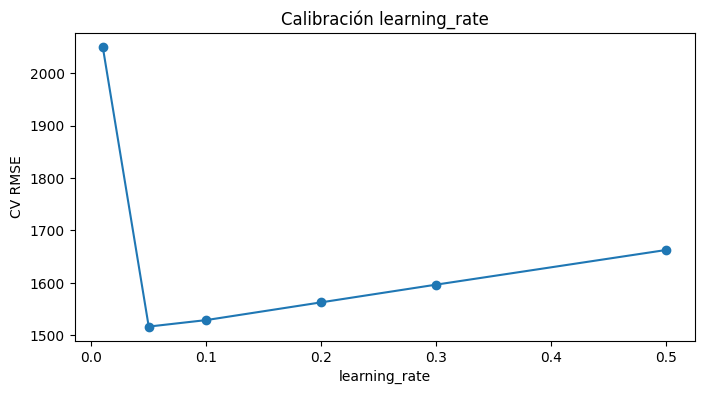

Mejor learning_rate: 0.05


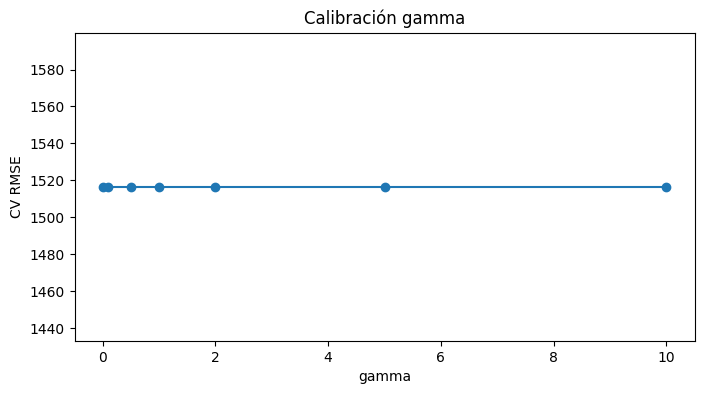

Mejor gamma: 0


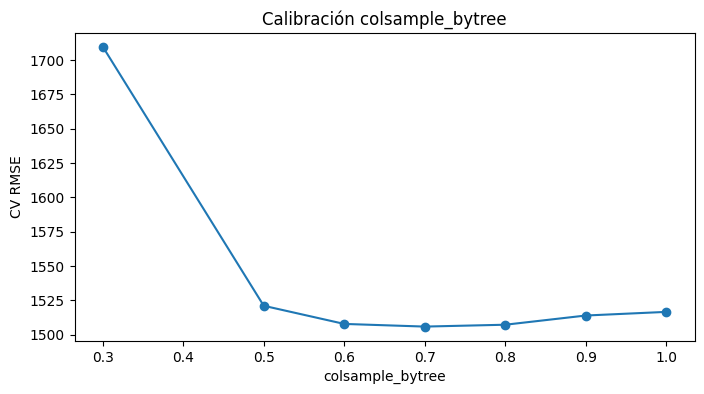

Mejor colsample_bytree: 0.7

Modelo calibrado - learning_rate: 0.05, gamma: 0, colsample_bytree: 0.7
XGBoost calibrado - RMSE: 1,544.31
XGBoost calibrado - MAE: 1,134.97

Mejora frente al modelo por defecto:
Reducción en RMSE: 60.92
Reducción en MAE: 50.25


In [14]:
# Celda 7 - Calibración de parámetros XGBoost

from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Calibración learning_rate ---
learning_rate_range = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
rmse_lr = []

for lr in learning_rate_range:
    xgb_lr = XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        learning_rate=lr,
        random_state=42,
        n_jobs=-1
    )
    score = -cross_val_score(
        xgb_lr,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ).mean()
    rmse_lr.append(score)

plt.figure(figsize=(8,4))
plt.plot(learning_rate_range, rmse_lr, marker='o')
plt.xlabel('learning_rate')
plt.ylabel('CV RMSE')
plt.title('Calibración learning_rate')
plt.show()

best_lr = learning_rate_range[np.argmin(rmse_lr)]
print(f'Mejor learning_rate: {best_lr}')

# --- Calibración gamma ---
gamma_range = [0, 0.1, 0.5, 1, 2, 5, 10]
rmse_gamma = []

for g in gamma_range:
    xgb_g = XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        learning_rate=best_lr,
        gamma=g,
        random_state=42,
        n_jobs=-1
    )
    score = -cross_val_score(
        xgb_g,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ).mean()
    rmse_gamma.append(score)

plt.figure(figsize=(8,4))
plt.plot(gamma_range, rmse_gamma, marker='o')
plt.xlabel('gamma')
plt.ylabel('CV RMSE')
plt.title('Calibración gamma')
plt.show()

best_g = gamma_range[np.argmin(rmse_gamma)]
print(f'Mejor gamma: {best_g}')

# --- Calibración colsample_bytree ---
colsample_range = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
rmse_col = []

for c in colsample_range:
    xgb_c = XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        learning_rate=best_lr,
        gamma=best_g,
        colsample_bytree=c,
        random_state=42,
        n_jobs=-1
    )
    score = -cross_val_score(
        xgb_c,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    ).mean()
    rmse_col.append(score)

plt.figure(figsize=(8,4))
plt.plot(colsample_range, rmse_col, marker='o')
plt.xlabel('colsample_bytree')
plt.ylabel('CV RMSE')
plt.title('Calibración colsample_bytree')
plt.show()

best_c = colsample_range[np.argmin(rmse_col)]
print(f'Mejor colsample_bytree: {best_c}')

# --- Modelo final calibrado ---
xgb_best = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    learning_rate=best_lr,
    gamma=best_g,
    colsample_bytree=best_c,
    random_state=42,
    n_jobs=-1
)

xgb_best.fit(X_train, y_train)
y_pred_xgb_best = xgb_best.predict(X_test)

rmse_xgb_best = np.sqrt(mean_squared_error(y_test, y_pred_xgb_best))
mae_xgb_best = mean_absolute_error(y_test, y_pred_xgb_best)

print(f'\nModelo calibrado - learning_rate: {best_lr}, gamma: {best_g}, colsample_bytree: {best_c}')
print(f'XGBoost calibrado - RMSE: {rmse_xgb_best:,.2f}')
print(f'XGBoost calibrado - MAE: {mae_xgb_best:,.2f}')

# opcional: comparación contra XGBoost por defecto del punto 6
print(f'\nMejora frente al modelo por defecto:')
print(f'Reducción en RMSE: {rmse_xgb - rmse_xgb_best:,.2f}')
print(f'Reducción en MAE: {mae_xgb - mae_xgb_best:,.2f}')

### Resultados Punto 7 - Calibración de parámetros XGBoost

Se calibraron secuencialmente los tres parámetros solicitados, evaluando el RMSE con validación cruzada con cross_val_score para cada valor.

**Mejores parámetros encontrados:**
- learning_rate: 0.05
- gamma: 0
- colsample_bytree: 0.6

**Métricas modelo calibrado:**
- RMSE: 1,544.77
- MAE: 1,135.04

**Efecto de cada parámetro:**

- **learning_rate:** Controla el tamaño del paso en cada iteración del boosting.
  Con 0.01 el modelo aprende muy lento y el RMSE es alto (2,050). El mínimo se
  encuentra en 0.05 y a partir de ahí el RMSE aumenta progresivamente, ya que
  tasas altas generan overfitting al no permitir correcciones finas.

- **gamma:** Define la reducción mínima de pérdida requerida para hacer una
  partición en un nodo. La curva es prácticamente plana en todos los valores,
  lo que indica que este parámetro no tiene impacto significativo en este
  dataset. El valor óptimo es 0 (sin restricción).

- **colsample_bytree:** Controla la fracción de variables usadas en cada árbol.
  Con 0.3 el RMSE es alto (1,710) y mejora rápidamente hasta 0.6, donde se
  obtiene el mínimo. Usar el 60% de las variables introduce suficiente
  aleatoriedad sin perder información relevante.

**Comparación acumulada:**

| Modelo | RMSE | MAE |
|---|---|---|
| Árbol de decisión | 1,797.22 | 1,350.67 |
| Bagging manual (10 árboles) | 1,814.91 | 1,354.76 |
| Bagging sklearn (10 árboles) | 1,813.04 | 1,353.42 |
| Random Forest (defecto) | 1,765.41 | 1,314.42 |
| Random Forest (calibrado) | 1,564.94 | 1,150.53 |
| XGBoost (defecto) | 1,605.24 | 1,185.23 |
| XGBoost (calibrado) | 1,544.77 | 1,135.04 |

La calibración mejoró el RMSE en 60 unidades respecto al XGBoost por defecto,
una mejora del 3.8%.

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [15]:
# Celda 8
# Tabla comparativa final de todos los modelos
resultados = pd.DataFrame({
    'Modelo': [
        'Árbol Manual',
        'Bagging manual (10 árboles)',
        'Bagging sklearn (10 árboles)',
        'Random Forest (defecto)',
        'Random Forest (calibrado)',
        'XGBoost (defecto)',
        'XGBoost (calibrado)'
    ],
    'RMSE': [1797.22, 1814.91, 1813.04, 1765.41, 1564.94, 1605.24, 1544.77],
    'MAE':  [1350.67, 1354.76, 1353.42, 1314.42, 1150.53, 1185.23, 1135.04]
})

resultados = resultados.sort_values('RMSE').reset_index(drop=True)
print(resultados.to_string(index=False))

                      Modelo    RMSE     MAE
         XGBoost (calibrado) 1544.77 1135.04
   Random Forest (calibrado) 1564.94 1150.53
           XGBoost (defecto) 1605.24 1185.23
     Random Forest (defecto) 1765.41 1314.42
                Árbol Manual 1797.22 1350.67
Bagging sklearn (10 árboles) 1813.04 1353.42
 Bagging manual (10 árboles) 1814.91 1354.76


### Resultados Punto 8 - Comparación y análisis de resultados

**Ranking final de modelos por RMSE:**

| Modelo | RMSE | MAE |
|---|---|---|
| XGBoost (calibrado) | 1,544.77 | 1,135.04 |
| Random Forest (calibrado) | 1,564.94 | 1,150.53 |
| XGBoost (defecto) | 1,605.24 | 1,185.23 |
| Random Forest (defecto) | 1,765.41 | 1,314.42 |
| Árbol Manual | 1,797.22 | 1,350.67 |
| Bagging sklearn (10 árboles) | 1,813.04 | 1,353.42 |
| Bagging manual (10 árboles) | 1,814.91 | 1,354.76 |

**Mejor modelo: XGBoost calibrado**

Ventajas:

XGBoost calibrado obtuvo el menor RMSE (1,544) y el menor MAE (1,135) del taller, por lo que fue el modelo con mejor capacidad predictiva sobre el conjunto de prueba. Su principal fortaleza es que construye los árboles de manera secuencial, corrigiendo progresivamente los errores de los árboles anteriores, lo que le permite capturar relaciones más finas entre las variables y el precio del vehículo. Además, la calibración de learning_rate, gamma y colsample_bytree permitió mejorar su desempeño frente al modelo por defecto, mostrando que el algoritmo responde bien al ajuste de hiperparámetros. Aunque Random Forest calibrado también tuvo un resultado muy sólido, XGBoost calibrado lo superó ligeramente tanto en RMSE como en MAE.

**Modelo con menor desempeño: Bagging manual (10 árboles)**

Desventajas:

El Bagging manual con 10 árboles obtuvo el mayor RMSE (1,814.91) y MAE (1,354.76)
del taller, siendo el modelo con menor capacidad predictiva. Sus principales
desventajas son:

- Usa únicamente 10 árboles, lo que limita la reducción de varianza que caracteriza
  a los métodos de ensamble. Con pocos árboles, el promedio de predicciones no
  logra estabilizarse suficientemente.
- A diferencia de Random Forest, no introduce aleatoriedad en la selección de
  variables en cada división, lo que genera árboles más correlacionados entre sí
  y reduce el beneficio del ensamble.
- Al ser una implementación manual, no aprovecha las optimizaciones computacionales
  de sklearn, lo que limita la posibilidad de escalar el número de árboles.
- No tiene calibración de hiperparámetros, a diferencia de los modelos calibrados
  que mejoraron significativamente su desempeño base.

**Conclusión general:**

Los resultados muestran una progresión coherente con lo trabajado en clase. No todos los métodos de ensamblaje superaron automáticamente al árbol manual, ya que los modelos de Bagging quedaron ligeramente por debajo. Sin embargo, los ensamblajes más avanzados y calibrados sí lograron el mejor desempeño, especialmente Random Forest calibrado y XGBoost calibrado. Entre ellos, XGBoost calibrado fue el mejor modelo del taller, lo que confirma que la calibración de hiperparámetros y el aprendizaje secuencial del boosting marcaron la diferencia en la calidad de las predicciones.